In [13]:
# capstone project -- function 1 (2D), week 4

import numpy as np
import matplotlib.pyplot as plt

from scipy.spatial import Delaunay, ConvexHull

from bayes_tools import (
    fitting,
    normalize, initial_bounds, validate_bounds_consistency,
    generate_next_point, ucb_acquisition,
    append_observations, fit_gp, get_length_scales, loo_predictions,
    fit_y_scale, to_scaled_units,
    compare_kappa_proposals, print_kappa_comparison,
)
from viz_tools import plot_2d_bo, plot_loo_calibration, plot_kappa_sensitivity


# Function 1

2D. Changed to modelling log10 y instead of y and changed the bounding box padding: the y magnitude  in the observed data is huge and this resolves that to some degree.

## Why `log10|y|`

`|y|` spans more than 100 orders of magnitude.. After `fit_gp`'s internal `normalize_y`, eleven of the twelve observations become the *identical* value `0.301511`. Leave-one-out on `y`: R² **−0.56**, and it puts only **42% of point pairs in the right order** — worse than a coin flip. On `log10|y|`: R² **+0.68** and **86%** of pairs ordered correctly, with neither ARD length-scale pinned.

## The live limitation: UCB on `log10|y|` is sign-blind

`log10|y|` models **magnitude**, so UCB maximises `|y|` — but we want `max y`, and on this function the largest `|y|` on record is **negative** (`−3.6e-3` at (0.650114, 0.681526), 13 orders above anything else). So the surrogate's own peak is a place we do *not* want to go, and UCB cannot tell the difference.

So, kappa is really important.

| `kappa` | proposal | distance to the negative peak |
|---|---|---|
| 0.5 | `[0.6426, 0.6086]` | **0.073** — effectively resampling it |
| 1.0 | `[0.6512, 0.5900]` | 0.092 |
| 2.0 | `[0.6673, 0.5618]` | 0.121 |
| 3.0 | `[0.6770, 0.5407]` | 0.143 |
| ≥ 4.0 | `[0.0825, 0.8799]` | 0.601 — **both axes on the box edge** |

Re-measured after the week-4 observation at `[0.53388, 0.493601]` (`y =
8.27e-14`) landed almost exactly on the prior week's proposal: that single
point moved the mode switch from `kappa 8 → 10` to `kappa 3 → 4`, and pulled
`kappa=3`'s own proposal from 0.221 to 0.143 away from the negative peak —
closer to the wrong-sign region, not farther. `KAPPA = 3.0` is now the last
usable step before the mode switch, not comfortably inside the stable window. Watch
this sweep again next week rather than assuming the margin holds.


Backtesting and testing various values of kappa suggests that the current approach - ucb with kappa = 3 is still the best approach. Backtesting against the other acquisition functions suggest that they all perform worse than this one.

In [14]:
X_initial = np.load("initial_data/function_1/initial_inputs.npy")
y_initial = np.load("initial_data/function_1/initial_outputs.npy")
D = X_initial.shape[1]

assert D == 2, f"Expected a 2D problem, got {D}D input -- check the loaded file."

# Once, at the very start of the capstone:
new_X = np.empty((0, D))
new_y = np.empty((0,))


## Update this once per week

Include the new X and y values from the previous week

In [3]:
new_X = np.array([
    [0.760601, 0.199726],   # week 2
    [0.885365, 0.523889],   # week 3
    [0.53388 , 0.493601],   # week 4 
])

new_y = np.array([
    -3.77292444076289e-115,
    2.3947473571694736e-54,
    8.272538373527034e-14
])

print("observations collected so far:", len(new_y))


weekly store: 4 resulted observation(s), 1 pending proposal [0.598885 0.602451]
  NOTE the pending row will be REPLACED when this notebook saves its proposal
observations collected so far: 4


## Build the full dataset (initial + everything collected so far)

In [4]:
X, y = append_observations(X_initial, y_initial, new_X, new_y)

print("X_initial shape:", X_initial.shape, "| y_initial shape:", y_initial.shape)
print("new_X shape:     ", new_X.shape, "| new_y shape:     ", new_y.shape)
print("combined X shape:", X.shape, "| combined y shape:", y.shape)

print("\nX range per dimension:")
print("  min:", X.min(axis=0))
print("  max:", X.max(axis=0))
print("y range:", y.min(), "to", y.max())

bounds_standard = initial_bounds(X_initial, pad_fraction=1.0, lower_limit=0.0,
                        upper_limit=1.0)
validate_bounds_consistency(X, bounds_standard)


bounds_box = np.column_stack([X.min(axis=0), X.max(axis=0)])
validate_bounds_consistency(X, bounds_box)

bounds = bounds_box

print("\nstandard bounds (pad_fraction=1.0):\n", np.round(bounds_standard, 4))
print("\nobserved bounding box (USED THIS WEEK):\n", np.round(bounds_box, 4))

print("\nfraction of each standard-bounds axis actually covered by data:")
frac = 1.0
for d in range(D):
    f = (X[:, d].max() - X[:, d].min()) / (bounds_standard[d, 1] - bounds_standard[d, 0])
    frac *= f
    print(f"  x{d}: {f:.1%}")
print(f"  -> {frac:.1%} of the standard box by volume; the rest is extrapolation")

# How loose is the box as a stand-in for "where the data is"?
hull = Delaunay(X)
box_volume = float(np.prod(bounds_box[:, 1] - bounds_box[:, 0]))
ch_volume = ConvexHull(X).volume
print(f"\nbounding box area {box_volume:.5f} | convex hull area {ch_volume:.5f}"
      f" ({ch_volume / box_volume:.1%} of the box)")
print(f"{len(ConvexHull(X).vertices)} of {len(X)} observations are hull vertices")


## Three candidate modelling targets

The first decision each week is *what to model*, not which acquisition to use — dynamic range is the dominant problem.

`|y|` spans 121 orders of magnitude. In float64, every observation but the single value at −3.6e-3 is numerically zero relative to it, so a GP on `y` can't tell the incumbent best (7.7e-16) from the worst point on record (3.3e-124).

Three targets:

- **`y_scaled`** — `y` over its standard deviation. Old choice, kept as baseline; a linear rescale changes nothing about the dynamic range.
- **`y_logmag`** — `log10|y|`, floored at `LOG_FLOOR` so an exact zero stays representable. The live target.
- **`y_sign`** — `sign(y)` as ±1, checking whether the sign half of the decomposition is modellable yet.

In [5]:
# log10|y| is undefined at y == 0, so floor the magnitude. -130 sits below the
# smallest observed log10|y| (-123.5), so no real observation is clipped  - if
# ever see zero it won't fail.
LOG_FLOOR = -130.0

y_sign = np.sign(y)
y_logmag = np.log10(np.maximum(np.abs(y), 10.0 ** LOG_FLOOR))

# The old parameterisation, kept ONLY as the baseline scored in the next cell.
# Nothing downstream of the LOO comparison uses it -- the live unit system is
# log10|y|, and mixing the two would silently corrupt everything.
y_scale = fit_y_scale(y)
y_scaled = to_scaled_units(y, y_scale)

print("=== let's show the huge range of magnitude ===")
nz = np.abs(y[y != 0])
print(f"|y| spans log10 {np.log10(nz).min():.1f} to {np.log10(nz).max():.1f}"
      f"  -> {np.log10(nz).max() - np.log10(nz).min():.0f} orders of magnitude")
print(f"signs: {(y > 0).sum()} positive, {(y < 0).sum()} negative, {(y == 0).sum()} zero")
print(f"largest |y|:  {np.abs(y).max():.4e}  (sign {'+' if y[np.argmax(np.abs(y))] > 0 else '-'})")
print(f"incumbent y:  {y.max():.4e}")
print(f"ratio:        {np.abs(y).max() / abs(y.max()):.3e}"
      f"  -> the incumbent is {np.log10(np.abs(y).max() / abs(y.max())):.0f} orders below the"
      " largest magnitude, so in float64 it is indistinguishable from 0 to a GP fit on y")

print("\n=== the three targets ===")
print(f"y_scaled : range [{y_scaled.min():+.4g}, {y_scaled.max():+.4g}]"
      f"   (y_scale = {y_scale:.6g}; a LINEAR rescale -- dynamic range unchanged)")
print(f"y_logmag : range [{y_logmag.min():+.2f}, {y_logmag.max():+.2f}]"
      f"   spread {y_logmag.max() - y_logmag.min():.1f}")
print(f"y_sign   : {int((y_sign > 0).sum())} at +1, {int((y_sign < 0).sum())} at -1")

print("\n=== the data, ranked by y (what we actually maximise) ===")
print(f"{'rank':>4} {'x0':>10} {'x1':>10} {'y':>13} {'sign':>5} {'log10|y|':>9}")
for r, i in enumerate(np.argsort(-y)):
    print(f"{r + 1:>4} {X[i, 0]:>10.6f} {X[i, 1]:>10.6f} {y[i]:>13.4e}"
          f" {'+' if y[i] > 0 else '-':>5} {y_logmag[i]:>9.2f}")

# Landmarks reused below. These are NOT the same point, and that is the whole
# difficulty: the magnitude peak -- which is what log10|y| makes the GP chase --
# is negative, while the incumbent we are trying to beat is positive.
i_pos_max = int(np.argmax(y))          # largest y  (the incumbent)
i_abs_max = int(np.argmax(np.abs(y)))  # largest |y| (the magnitude peak)
p_pos, neg_peak = X[i_pos_max], X[i_abs_max]

print(f"\nincumbent (max y)       : {np.round(p_pos, 6)}  y = {y[i_pos_max]:+.4e}")
print(f"magnitude peak (max |y|): {np.round(neg_peak, 6)}  y = {y[i_abs_max]:+.4e}"
      "   <- NEGATIVE")
print(f"separation: {np.linalg.norm(p_pos - neg_peak):.4f}")


=== let's show the huge range of magnitude ===
|y| spans log10 -123.5 to -2.4  -> 121 orders of magnitude
signs: 9 positive, 4 negative, 0 zero
largest |y|:  3.6061e-03  (sign -)
incumbent y:  8.2725e-14
ratio:        4.359e+10  -> the incumbent is 11 orders below the largest magnitude, so in float64 it is indistinguishable from 0 to a GP fit on y

=== the three targets ===
y_scaled : range [-3.753, +8.609e-11]   (y_scale = 0.000960905; a LINEAR rescale -- dynamic range unchanged)
y_logmag : range [-123.48, -2.44]   spread 121.0
y_sign   : 9 at +1, 4 at -1

=== the data, ranked by y (what we actually maximise) ===
rank         x0         x1             y  sign  log10|y|
   1   0.533880   0.493601    8.2725e-14     +    -13.08
   2   0.731024   0.733000    7.7109e-16     +    -15.11
   3   0.683418   0.861057    2.5350e-40     +    -39.60
   4   0.574329   0.879898    1.0331e-46     +    -45.99
   5   0.883890   0.582254    6.2299e-48     +    -47.21
   6   0.885365   0.523889    2.3947

## The evidence: leave-one-out on each target

Refits the GP twelve times per target, holding out one observation each time and predicting it from the other eleven. Four columns:

- **LOO R²** — below 0 is worse than predicting the mean.
- **pairs ordered right** — the one that matters. Over every pair, how often does the surrogate rank them the same way as reality? 50% is a coin flip, and ordering is all an acquisition function ever uses the posterior mean for.
- **mean |z| / median |z|** — calibration; read together since the mean here is dominated by one point.
- **pinned length-scales** — whether the GP has given up on an axis.

Expect `log10|y|` to win on all four and `sign(y)` to fail — that failure is why sign is measured weekly rather than predicted.

In [6]:
LOO_GP_KWARGS = {"n_restarts_optimizer": 15}


def pairs_ordered_right(actual, predicted):
    """Fraction of observation PAIRS the surrogate puts in the correct order.

    This is the property an acquisition function actually depends on: it never
    uses the posterior mean's absolute value, only comparisons between
    candidates when taking an argmax. 50% is a coin flip. Ties in `actual` are
    skipped, so the denominator is the number of genuinely ordered pairs.

    Plain counting -- no rank statistics involved.
    """
    n = len(actual)
    total = right = 0
    for i in range(n):
        for j in range(i + 1, n):
            if actual[i] == actual[j]:
                continue
            total += 1
            right += (actual[i] > actual[j]) == (predicted[i] > predicted[j])
    return right / total, right, total


# leave one out cross-validation
def loo_score(name, target):
    """Refit once per held-out point; return predictive power and calibration.

    Deliberately does NOT print. sklearn raises ~26 ConvergenceWarnings per
    target here (12 leave-one-out refits plus one full fit), and printing each
    row as soon as it was computed put those warnings *between* the rows and
    made the table unreadable. The caller does all the fitting first, then
    prints the table in one block.
    """
    mu, sd = loo_predictions(X, target, bounds, gp_kwargs=LOO_GP_KWARGS)
    resid = target - mu
    r2 = 1.0 - float(np.sum(resid ** 2)) / float(np.sum((target - target.mean()) ** 2))
    order_frac, n_right, n_pairs = pairs_ordered_right(target, mu)
    z = np.abs(resid / sd)

    gp = fit_gp(X, target, bounds, n_restarts_optimizer=20, random_state=0)
    ls = get_length_scales(gp)
    pinned = [d for d, v in enumerate(ls)
              if v <= 1.01e-2 or v >= 0.99 * 10.0]

    return {"name": name, "r2": r2, "order_frac": order_frac,
            "mean_abs_z": float(z.mean()), "median_abs_z": float(np.median(z)),
            "length_scales": ls, "pinned": pinned,
            # Row text is built here but printed later, once fitting is over.
            "row": (f"{name:>24} | {r2:>+7.3f} | {order_frac:>6.1%}"
                    f" ({n_right:>2}/{n_pairs:<2}) | {z.mean():>9.3g}"
                    f" | {np.median(z):>8.2f} | {z.max():>8.3g}"
                    f" | {str(np.round(ls, 3)):>16} | {pinned if pinned else 'none'}")}


# ALL the fitting happens inside this block, so no warning can land mid-table.
with fitting("leave-one-out over 3 candidate targets"):
    scores = {
        "linear": loo_score("y linear (old choice)", y_scaled),
        "logmag": loo_score("log10|y| (NEW)", y_logmag),
        "sign":   loo_score("sign(y) as +/-1", y_sign),
    }

print("  -> each one reports a hyperparameter pinned at a bound, which is exactly")
print("     what the `pinned` column below records on purpose.")
print("     Pinned means the GP treats that axis as irrelevant; raising the bound")
print("     does not help, it just moves where the pin sits.")

# The table, now guaranteed contiguous.
print(f"\n{'modelling target':>24} | {'LOO R2':>7} | {'pairs ordered right':>19} | {'mean|z|':>9}"
      f" | {'med|z|':>8} | {'max|z|':>8} | {'length-scales':>16} | pinned")
print("-" * 132)
for s in scores.values():
    print(s["row"])

print()


[fitting: leave-one-out over 3 candidate targets] 73 warnings held back, 3 distinct:
    44 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
    16 x  ConvergenceWarning  k1__k2__length_scale (dim 0) pinned at upper bound 10.0
    13 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
  -> each one reports a hyperparameter pinned at a bound, which is exactly
     what the `pinned` column below records on purpose.
     Pinned means the GP treats that axis as irrelevant; raising the bound
     does not help, it just moves where the pin sits.

        modelling target |  LOO R2 | pairs ordered right |   mean|z| |   med|z| |   max|z| |    length-scales | pinned
------------------------------------------------------------------------------------------------------------------------------------
   y linear (old choice) |  -0.544 |  44.9% (35/78) |  1.27e+10 |     0.24 | 1.65e+11 |  [ 0.027 10.   ] | [1]
          log10|y| (NEW) |  +0.746 | 

## Which dimension matters, under each parameterisation

Checking both, since the old target's answer was an artefact. On linearly-rescaled `y`, the GP reports x0 ≈ 0.013 (bottom of `length_scale_bounds`) and x1 = 10.0 (pinned at the top) — "x0 is a spike, x1 is irrelevant". That's what fitting a single non-zero observation looks like, not a finding about the function.

On `log10|y|`, both length-scales come back around 0.11–0.13 with neither pinned — real structure on both axes.

In [7]:
PINNED_LO, PINNED_HI = 1e-2, 10.0  # fit_gp's default length_scale_bounds

# Fit both targets up front so the printing below is uninterrupted. gp_check is
# reused by the kappa sweep and the contour plot.
with fitting("one GP per candidate target"):
    gp_check = fit_gp(X, y_logmag, bounds, n_restarts_optimizer=20, random_state=0)
    fitted = {
        "y linear (old)": fit_gp(X, y_scaled, bounds, n_restarts_optimizer=20,
                                 random_state=0),
        "log10|y| (live)": gp_check,
    }

for label, gp_t in fitted.items():
    ls = get_length_scales(gp_t)
    print(f"{label}:")
    for dim, v in sorted(enumerate(ls), key=lambda t: t[1]):
        tag = ""
        if v <= 1.01 * PINNED_LO:
            tag = "  <- PINNED at the LOWER bound (delta spike; not a real length-scale)"
        elif v >= 0.99 * PINNED_HI:
            tag = "  <- PINNED at the UPPER bound (GP calls this axis irrelevant)"
        print(f"  x{dim}: length_scale = {v:.4f}{tag}")
    print(f"  kernel: {gp_t.kernel_}\n")



[fitting: one GP per candidate target] 3 warnings held back, 2 distinct:
     2 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
     1 x  ConvergenceWarning  k1__k2__length_scale (dim 1) pinned at upper bound 10.0
y linear (old):
  x0: length_scale = 0.0265
  x1: length_scale = 10.0000  <- PINNED at the UPPER bound (GP calls this axis irrelevant)
  kernel: 1.04**2 * Matern(length_scale=[0.0265, 10], nu=2.5) + WhiteKernel(noise_level=1e-06)

log10|y| (live):
  x0: length_scale = 0.2870
  x1: length_scale = 0.3537
  kernel: 1.06**2 * Matern(length_scale=[0.287, 0.354], nu=2.5) + WhiteKernel(noise_level=1e-06)



## Comparing kappa before I commit

No real evaluation spent: one GP fit on `log10|y|`, checking where each `kappa` would send us right now. `kappa` is dimensionless, so the target choice doesn't affect it — the retargeting just means these numbers now come from a GP that actually fits.

Three things to read off:

1. **Does the proposal keep moving?** Once it stops, more `kappa` buys nothing.
2. **Is there a mode switch?** Matters more than saturation — here it's between `kappa` 8 and 10.
3. **How close does it drift to the negative magnitude peak?** Specific to this function: low `kappa` exploits straight into the one high-magnitude region known to be the wrong sign.

[fitting: kappa sweep + bounds cross-check] 2 warnings held back:
     2 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
   kappa |                   x_next |  acq_value |  pred_mean |  pred_std |  dist_from_best
-------------------------------------------------------------------------------------------
     0.5 |            [0.643,0.609] |     2.9003 |    -0.7879 |    7.3763 |          0.0733
       1 |            [0.651,0.59 ] |     7.1252 |    -2.3540 |    9.4792 |          0.0916
       2 |            [0.667,0.562] |    18.3004 |    -6.9339 |   12.6171 |          0.1209
       3 |            [0.677,0.541] |    31.9416 |   -11.5816 |   14.5077 |          0.1433
       4 |            [0.083,0.88 ] |    57.6392 |   -76.1197 |   33.4397 |          0.6013
       5 |            [0.083,0.88 ] |    91.0789 |   -76.1197 |   33.4397 |          0.6013
       8 |            [0.083,0.88 ] |   191.3981 |   -76.1197 |   33.4397 |          0.6013
      10 |            [0

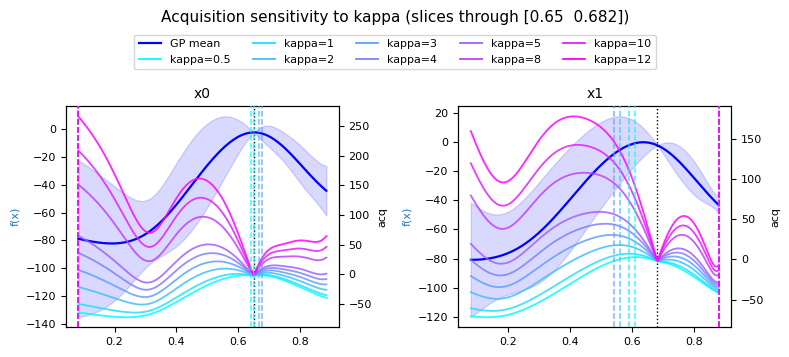

In [8]:
# Both the sweep and the bounds cross-check fit happen here, before any
# printing, so nothing interrupts the two tables below.
with fitting("kappa sweep + bounds cross-check"):
    kappa_rows = compare_kappa_proposals(
        X, y_logmag, bounds,
        kappa_values=[0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 8.0, 10.0, 12.0],
        maximize=True, n_restarts=60, random_state=0)
    x_corner, _ = generate_next_point(X, y_logmag, bounds_standard, acquisition="ucb",
                                      kappa=3.0, maximize=True, n_restarts=40,
                                      random_state=0)
in_data = bool(np.all(X.min(axis=0) <= x_corner) and np.all(x_corner <= X.max(axis=0)))

print_kappa_comparison(kappa_rows)

# The function-1-specific read: UCB on log10|y| maximises MAGNITUDE and is blind
# to sign, so track how close each proposal drifts to the negative peak.
print(f"\n{'kappa':>6} {'x_next':>20} {'d(neg peak)':>12} {'d(incumbent)':>13}"
      f" {'nearest obs':>20} {'sign':>5} {'on box edge':>12}")
for r in kappa_rows:
    xn = np.asarray(r["x_next"])
    dists = np.linalg.norm(X - xn, axis=1)
    j = int(np.argmin(dists))
    edge = [f"x{k}" for k in range(D)
            if np.isclose(xn[k], bounds[k, 0], atol=1e-6)
            or np.isclose(xn[k], bounds[k, 1], atol=1e-6)]
    print(f"{r['kappa']:>6.1f} {str(np.round(xn, 4)):>20}"
          f" {np.linalg.norm(xn - neg_peak):>12.4f} {np.linalg.norm(xn - p_pos):>13.4f}"
          f" {str(np.round(X[j], 4)):>20} {'+' if y[j] > 0 else '-':>5}"
          f" {','.join(edge) or 'none':>12}")

# The bounds cross-check computed above: this is the evidence that the box-bounds
# deviation is load-bearing rather than a preference. Under the project-standard
# pad_fraction=1.0 bounds, the same GP and kappa run off to the far corner.
print(f"\nsame GP/kappa under bounds_standard would propose {np.round(x_corner, 4)}"
      f" -- inside the observed data: {in_data}")
print(f"  (bounds_standard upper corner is {np.round(bounds_standard[:, 1], 4)})")

fig = plot_kappa_sensitivity(X, y_logmag, bounds, gp_check, kappa_rows,
                             ucb_acquisition, maximize=True)
plt.show()

# Committed choice -- reused by the proposal, the contour plot, and the
# diagnostics replay below, so it's harder to make a mistake
KAPPA = 3.0



## Sign structure

Diagnostic only — nothing here changes the proposal, but `log10|y|` throws sign away, so it's invisible unless checked separately.

- **The magnitude peak is the wrong sign.** Largest `|y|` is `−3.6e-3`, 13 orders above anything else — the region the surrogate finds most attractive is one to avoid.
- **Opposite-sign pairs bracket a zero contour.** Between any positive and negative observation, `y` must cross zero. The closest such pair is 0.0959 apart — the incumbent and the magnitude peak are neighbours — so `max y` sits just on the positive side.

Also checks whether the incumbent is a genuine local maximum rather than a point near a zero crossing, via its LOO z-score on `log10|y|`: near 0 means the smooth magnitude trend already accounts for it.

Predicted magnitudes *inside* an opposite-sign pair are upper bounds, not estimates: `|y| → 0` at the contour so `log10|y| → −∞`, and a smooth GP with no data in the gap can't represent that dip.

In [9]:
# Refit without the incumbent FIRST (section 3 needs it), so this fit cannot
# interleave with sections 1-2 printed below.
mask = np.ones(len(y), bool)
mask[i_pos_max] = False
with fitting("refit leaving the incumbent out"):
    gp_wo = fit_gp(X[mask], y_logmag[mask], bounds, n_restarts_optimizer=25,
                   random_state=0)
mu_wo, sd_wo = gp_wo.predict(normalize(p_pos.reshape(1, -1), bounds), return_std=True)
z_inc = float((y_logmag[i_pos_max] - mu_wo[0]) / sd_wo[0])
verdict = ("on the smooth magnitude trend; fast decay explains it" if abs(z_inc) < 1.0
           else "anomalous -- may sit near a zero contour")

print("=== 1. the magnitude peak is NEGATIVE ===")
print(f"  largest |y| : {np.round(neg_peak, 6)}  y = {y[i_abs_max]:+.4e}   <- what")
print("                log10|y| makes the GP chase, and the wrong sign")
print(f"  incumbent   : {np.round(p_pos, 6)}  y = {y[i_pos_max]:+.4e}   <- what we")
print("                are actually trying to beat")
print(f"  separation  : {np.linalg.norm(p_pos - neg_peak):.4f}"
      f"  ({np.log10(abs(y[i_abs_max] / y[i_pos_max])):.0f} orders of magnitude apart)")

print("\n=== 2. opposite-sign pairs: each brackets a zero contour ===")
pos_idx = np.flatnonzero(y > 0)
neg_idx = np.flatnonzero(y < 0)
pairs = sorted(((float(np.linalg.norm(X[i] - X[j])), i, j)
                for i in pos_idx for j in neg_idx))
for dist, i, j in pairs[:4]:
    print(f"  dist={dist:.4f}  +{np.round(X[i], 4)} (y={y[i]:+.2e})"
          f"  <->  -{np.round(X[j], 4)} (y={y[j]:+.2e})")
print("  -> max y lies just on the positive side of one of these contours;")
print("     nothing in the surrogate knows where they are.")

print("\n=== 3. is the incumbent a real local max, or just near a zero crossing? ===")
print(f"  actual log10|y| = {y_logmag[i_pos_max]:.2f},"
      f" predicted from the other {mask.sum()} = {mu_wo[0]:.2f} +/- {sd_wo[0]:.2f}")
print(f"  z = {z_inc:+.2f}  ->  {verdict}")

print("\n=== 4. sign counts, for the record ===")
print(f"  {len(pos_idx)} positive, {len(neg_idx)} negative."
      " A GP on sign(y) scores LOO R2 = -0.82 on this (see the evidence table),")
print("  so sign is measured, never predicted.")


[fitting: refit leaving the incumbent out] 1 warning held back:
     1 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
=== 1. the magnitude peak is NEGATIVE ===
  largest |y| : [0.650114 0.681526]  y = -3.6061e-03   <- what
                log10|y| makes the GP chase, and the wrong sign
  incumbent   : [0.53388  0.493601]  y = +8.2725e-14   <- what we
                are actually trying to beat
  separation  : 0.2210  (11 orders of magnitude apart)

=== 2. opposite-sign pairs: each brackets a zero contour ===
  dist=0.0959  +[0.731 0.733] (y=+7.71e-16)  <->  -[0.6501 0.6815] (y=-3.61e-03)
  dist=0.1029  +[0.8404 0.2647] (y=+3.34e-124)  <->  -[0.7606 0.1997] (y=-3.77e-115)
  dist=0.1826  +[0.6834 0.8611] (y=+2.54e-40)  <->  -[0.6501 0.6815] (y=-3.61e-03)
  dist=0.2124  +[0.5743 0.8799] (y=+1.03e-46)  <->  -[0.6501 0.6815] (y=-3.61e-03)
  -> max y lies just on the positive side of one of these contours;
     nothing in the surrogate knows where they are.

=== 3

## Propose the next point

Plain UCB argmax on the `log10|y|` surrogate at the chosen `KAPPA`. Two checks after it:

- **Convex-hull membership** — the strong extrapolation test, the one that's trusted.
- **Sign of the nearest observations**, since the surrogate is sign-blind. Doesn't change the proposal, just sets expectations for the result.

In [10]:
with fitting("UCB proposal"):
    x_next, gp = generate_next_point(
        X, y_logmag, bounds,
        acquisition="ucb",
        kappa=KAPPA,        # see the comparison above
        maximize=True,
        n_restarts=25,
        random_state=0,
    )

print(f"--- Next point to evaluate (bounds shape {bounds.shape}) ---")
print("x_next:", np.round(x_next, 6))
print(gp.kernel_)

mu_log, sigma_log = gp.predict(normalize(x_next.reshape(1, -1), bounds), return_std=True)
print(f"\npredicted log10|y| = {mu_log[0]:+.3f} +/- {sigma_log[0]:.3f}"
      f"   -> |y| ~ 1e{mu_log[0]:.0f}")
print(f"largest |y| on record: {np.abs(y).max():.4e} (log10 = {y_logmag.max():.2f});"
      f" incumbent y = {y.max():.4e}")

print("\n--- extrapolation checks ---")
outside = [d for d in range(D) if not (X[:, d].min() <= x_next[d] <= X[:, d].max())]
print("outside the observed range on its own axis:", outside or "none")
on_edge = [f"x{d}" for d in range(D)
           if np.isclose(x_next[d], bounds[d, 0], atol=1e-6)
           or np.isclose(x_next[d], bounds[d, 1], atol=1e-6)]
print("on a box edge:", ",".join(on_edge) or "none")
print("inside the convex hull (the strong test):", bool(hull.find_simplex(x_next) >= 0))
print(f"distance from the incumbent: {np.linalg.norm(x_next - p_pos):.4f}")

print("\n--- sign-blindness check: what is nearby, and what sign is it? ---")
print(f"distance to the NEGATIVE magnitude peak: {np.linalg.norm(x_next - neg_peak):.4f}")
print("nearest 4 observations to x_next:")
for i in np.argsort(np.linalg.norm(X - x_next, axis=1))[:4]:
    print(f"  dist={np.linalg.norm(X[i] - x_next):.4f}  sign={'+' if y[i] > 0 else '-'}"
          f"  y={y[i]:+.4e}  x={np.round(X[i], 4)}")
n_neg_near = sum(1 for i in np.argsort(np.linalg.norm(X - x_next, axis=1))[:4] if y[i] < 0)
print(f"-> {n_neg_near} of the 4 nearest observations"
      f" {'is' if n_neg_near == 1 else 'are'} negative"
      + (", and it is the closest one" if n_neg_near and
         y[int(np.argmin(np.linalg.norm(X - x_next, axis=1)))] < 0 else "") + ".")
print("   UCB is maximising |y| and cannot see sign, so a negative result is a real")
print("   possibility here -- that is the cost of a magnitude-only surrogate.")

# Hard gates: never submit a point outside the data cloud or with a negative
# coordinate (X is known never to be negative).
assert bool(hull.find_simplex(x_next) >= 0), "x_next is outside the convex hull"
assert np.all(x_next >= 0.0), "X is never negative -- proposal has a negative coordinate"


[fitting: UCB proposal] 1 warning held back:
     1 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06
--- Next point to evaluate (bounds shape (2, 2)) ---
x_next: [0.677043 0.540748]
1.06**2 * Matern(length_scale=[0.287, 0.354], nu=2.5) + WhiteKernel(noise_level=1e-06)

predicted log10|y| = -11.582 +/- 14.508   -> |y| ~ 1e-12
largest |y| on record: 3.6061e-03 (log10 = -2.44); incumbent y = 8.2725e-14

--- extrapolation checks ---
outside the observed range on its own axis: none
on a box edge: none
inside the convex hull (the strong test): True
distance from the incumbent: 0.1507

--- sign-blindness check: what is nearby, and what sign is it? ---
distance to the NEGATIVE magnitude peak: 0.1433
nearest 4 observations to x_next:
  dist=0.1433  sign=-  y=-3.6061e-03  x=[0.6501 0.6815]
  dist=0.1507  sign=+  y=+8.2725e-14  x=[0.5339 0.4936]
  dist=0.1997  sign=+  y=+7.7109e-16  x=[0.731 0.733]
  dist=0.2090  sign=+  y=+2.3947e-54  x=[0.8854 0.5239]
-> 1 of the 4 nea

## Visualise the GP and acquisition function

Panels are in **`log10|y|` units**, not `y`.

Two things to check: the GP mean panel should show a single tight peak near (0.65, 0.68) — the magnitude peak, which is the *negative* observation — and the markers should show the sign structure (the peak and incumbent are neighbours with opposite signs, so a zero contour runs between them; the dashed line marks that pair). `x_next` is UCB's argmax, not placed relative to it.

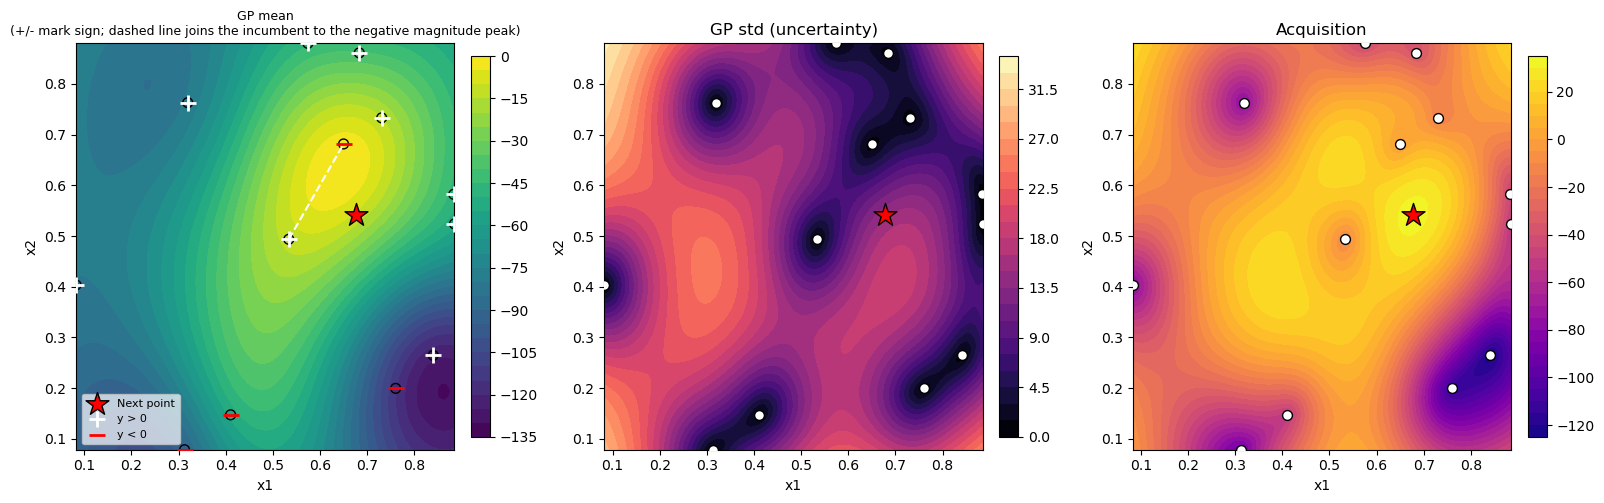

In [11]:
fig = plot_2d_bo(
    X, y_logmag, bounds, gp,
    acquisition_fn=ucb_acquisition,
    x_next=x_next,
    acq_kwargs={"kappa": KAPPA, "maximize": True},
    y_scale=None,   # panels are log10|y|; a linear y_scale does not apply here
)

# Mark the sign structure, which the colour scale alone cannot show.
ax = fig.axes[0]
ax.scatter(X[y > 0, 0], X[y > 0, 1], marker="+", s=140, c="white", linewidths=2.0,
           label="y > 0", zorder=6)
ax.scatter(X[y < 0, 0], X[y < 0, 1], marker="_", s=140, c="red", linewidths=2.0,
           label="y < 0", zorder=6)
ax.plot([p_pos[0], neg_peak[0]], [p_pos[1], neg_peak[1]], "w--", lw=1.5, zorder=5)
ax.legend(loc="lower left", fontsize=8, framealpha=0.7)
ax.set_title(ax.get_title() + "\n(+/- mark sign; dashed line joins the incumbent"
             " to the negative magnitude peak)", fontsize=9)
plt.show()


## Sanity-check the surrogate: leave-one-out calibration

Visual version of the evidence table above. Looking for points scattered about the diagonal with error bars that actually cover it.

[fitting: leave-one-out for the calibration plot] 13 warnings held back:
    13 x  ConvergenceWarning  k2__noise_level (dim 0) pinned at lower bound 1e-06


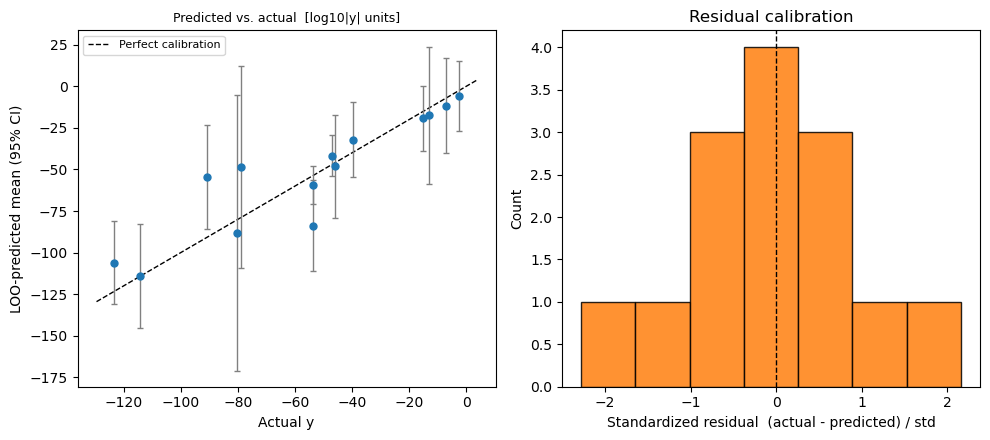

mean|z| = 0.81 (1.0 is ideal) | max|z| = 2.05
within 1 sigma: 9/13 | within 2 sigma: 12/13
worst-predicted point: x=[0.3127 0.0787] sign=- actual log10|y|=-90.7 predicted=-55.1 (z=-2.05)


In [12]:
with fitting("leave-one-out for the calibration plot"):
    pred_mean_log, pred_std_log = loo_predictions(
        X, y_logmag, bounds, gp_kwargs={"n_restarts_optimizer": 20})

# y_scale is NOT passed: these are log10|y| units, not a linear rescale of y.
fig = plot_loo_calibration(y_logmag, pred_mean_log, pred_std_log)
for ax in np.atleast_1d(fig.axes).ravel()[:1]:
    ax.set_title(ax.get_title() + "  [log10|y| units]", fontsize=9)
plt.show()

z = (y_logmag - pred_mean_log) / pred_std_log
print(f"mean|z| = {np.abs(z).mean():.2f} (1.0 is ideal) | max|z| = {np.abs(z).max():.2f}")
print(f"within 1 sigma: {int((np.abs(z) <= 1).sum())}/{len(z)}"
      f" | within 2 sigma: {int((np.abs(z) <= 2).sum())}/{len(z)}")
worst = int(np.argmax(np.abs(z)))
print(f"worst-predicted point: x={np.round(X[worst], 4)} sign={'+' if y[worst] > 0 else '-'}"
      f" actual log10|y|={y_logmag[worst]:.1f} predicted={pred_mean_log[worst]:.1f}"
      f" (z={z[worst]:+.2f})")


In [13]:
# The proposal as a hyphen-separated string, for submission.
print("-".join(f"{v:.6f}" for v in x_next))

# Full precision as well. 6 dp is fine to submit, but paste THIS into next
# week's new_X: a 6-dp copy of function 4's proposal rounded 4e-7 outside its
# own upper bound and tripped validate_bounds_consistency.
print("\nfull precision (use for next week's new_X):")
print("-".join(repr(float(v)) for v in x_next))



0.677043-0.540748

full precision (use for next week's new_X):
0.6770434944157266-0.5407478470003824


In [14]:
# I record this week's proposal in the weekly store. This rewrites
# inputs.csv rather than appending, so re-running the notebook cannot
# double-record. I submit the 6-dp string printed above -- it is the same value
# written here.
save_proposal(1, new_X, x_next)


wrote weekly_data/function_1/inputs.csv: 5 row(s) (4 resulted + 1 proposal)
  proposal row: 0.5988849367958297-0.6024505787039317


'weekly_data/function_1/inputs.csv'